In [15]:
from PIL import Image 
import requests 
from transformers import AutoModelForCausalLM 
from transformers import AutoProcessor 

model_id = "/mnt/petrelfs/songmingyang/songmingyang/model/mm/Phi-3-vision-128k-instruct" 

model = AutoModelForCausalLM.from_pretrained(model_id, device_map="cuda", trust_remote_code=True, torch_dtype="auto", _attn_implementation='flash_attention_2') # use _attn_implementation='eager' to disable flash attention

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True) 

messages = [ 
    # {"role": "user", "content": "<|image_1|>\nWhat is shown in this image?"}, 
    {"role": "user", "content": "who are you?"},
    # {"role": "assistant", "content": "The chart displays the percentage of respondents who agree with various statements about their preparedness for meetings. It shows five categories: 'Having clear and pre-defined goals for meetings', 'Knowing where to find the information I need for a meeting', 'Understanding my exact role and responsibilities when I'm invited', 'Having tools to manage admin tasks like note-taking or summarization', and 'Having more focus time to sufficiently prepare for meetings'. Each category has an associated bar indicating the level of agreement, measured on a scale from 0% to 100%."}, 
    # {"role": "user", "content": "Provide insightful questions to spark discussion."} 
] 

train_png="/mnt/petrelfs/songmingyang/code/mm/robustLMM/robustlmm/data_adjustment/diffusion_augment/train.jpg"

# url = "https://assets-c4akfrf5b4d3f4b7.z01.azurefd.net/assets/2024/04/BMDataViz_661fb89f3845e.png" 
image = Image.open(train_png).convert("RGB")





Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.57s/it]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [19]:
prompt = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# inputs = processor(prompt, [image], return_tensors="pt").to("cuda:0") 
inputs = processor(prompt,[],return_tensors="pt").to("cuda:0") 


IndexError: list index out of range

In [17]:
inputs.keys()

dict_keys(['input_ids', 'attention_mask'])

In [18]:
generation_args = { 
    "max_new_tokens": 500, 
    "temperature": 0.0, 
    "do_sample": False, 
} 

generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args) 

# remove input tokens 
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0] 

print(response)

I am Phi, an AI designed to provide information and assistance to users seeking knowledge on various topics.


### 2.TEST INSTRUCT BLIP

In [6]:
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch
from PIL import Image
import requests

model = InstructBlipForConditionalGeneration.from_pretrained("/mnt/petrelfs/songmingyang/songmingyang/model/mm/instruct_blip/instruct_blip_7b")
processor = InstructBlipProcessor.from_pretrained("/mnt/petrelfs/songmingyang/songmingyang/model/mm/instruct_blip/instruct_blip_7b")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

url = train_png
image = Image.open(url).convert("RGB")


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.76s/it]


In [37]:
prompt = "who are you?"
inputs = processor(images=None, text=prompt, return_tensors="pt").to(device)


In [38]:
import torch
inputs.keys()
inputs["pixel_values"]=torch.zeros(1,3,190,190).to(model.device).to(model.dtype)

In [39]:

outputs = model.generate(
        **inputs,
        do_sample=False,
        num_beams=5,
        max_length=256,
        min_length=1,
        top_p=0.9,
        repetition_penalty=1.5,
        length_penalty=1.0,
        temperature=1,
)
generated_text = processor.batch_decode(outputs, skip_special_tokens=True)[0].strip()
print(generated_text)

no one


In [1]:
from PIL import Image 
train_png="/mnt/petrelfs/songmingyang/code/mm/robustLMM/robustlmm/data_adjustment/diffusion_augment/train.jpg"

# url = "https://assets-c4akfrf5b4d3f4b7.z01.azurefd.net/assets/2024/04/BMDataViz_661fb89f3845e.png" 
image = Image.open(train_png).convert("RGB")


In [2]:
from lmms_eval.tasks.mmmu.utils_group_img import process_images
a = process_images([image])

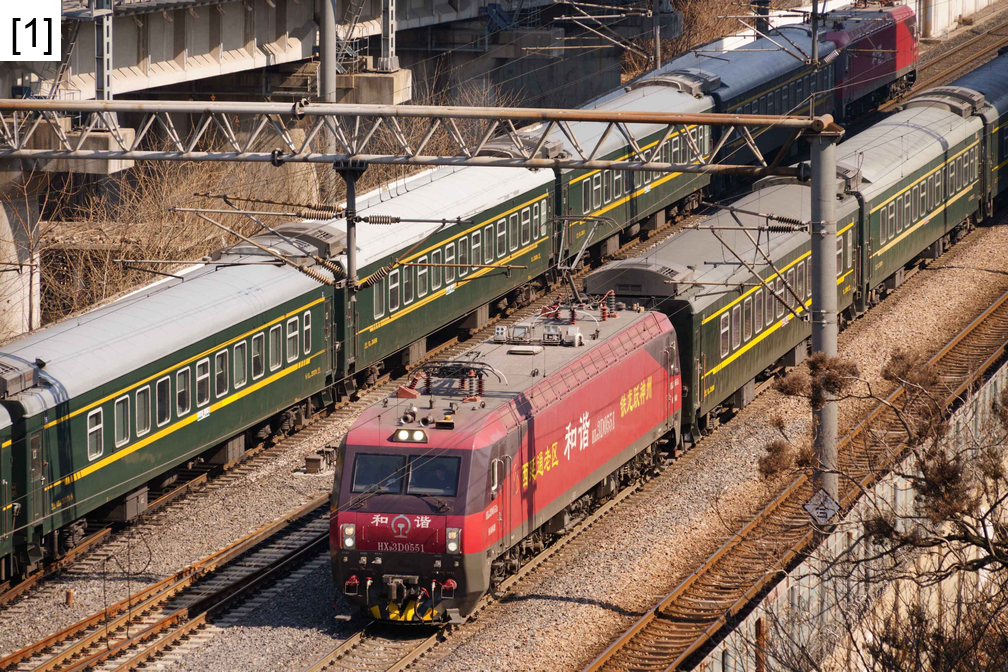

In [3]:
a

### TEST COGVLM

In [9]:
import torch
import logging
import copy
from tqdm import tqdm
from lmms_eval import utils
from lmms_eval.api.instance import Instance
from lmms_eval.api.model import lmms
from lmms_eval.api.registry import register_model
from accelerate import Accelerator, DistributedType
from accelerate.state import AcceleratorState
from accelerate import PartialState  
from typing import List, Optional, Union, Tuple
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration, Blip2ForConditionalGeneration,Blip2Processor

from lmms_eval.utils import stop_sequences_criteria


import warnings
import os, sys
import argparse
sys.path.append("/mnt/petrelfs/songmingyang/code/mm/MAPO/mhr/alignment/models/cogvlm/CogVLM")
from sat.model.mixins import CachedAutoregressiveMixin
from sat.quantization.kernels import quantize
from sat.model import AutoModel
from sat.mpu import get_model_parallel_world_size
from utils.utils import chat, llama2_tokenizer, llama2_text_processor_inference, get_image_processor
from utils.models import CogAgentModel, CogVLMModel

pretrained="/mnt/petrelfs/songmingyang/songmingyang/runs/cogvlm/base/cogvlm-chat-v1.1"
model, model_args = AutoModel.from_pretrained(
            pretrained,
            args=argparse.Namespace(
            deepspeed=None,
            local_rank=0,
            rank=0,
            world_size=1,
            model_parallel_size=1,
            mode='inference',
            skip_init=True,
            use_gpu_initialization=True,
            device="cuda:0",
            bf16=False,
            fp16=True,
        ), overwrite_args={})
model = model.eval()
model.add_mixin('auto-regressive', CachedAutoregressiveMixin())

[2024-08-21 17:46:08,127] [INFO] building CogVLMModel model ...
[2024-08-21 17:46:08,138] [INFO] [RANK 0] > initializing model parallel with size 1
[2024-08-21 17:46:08,139] [INFO] [RANK 0] You didn't pass in LOCAL_WORLD_SIZE environment variable. We use the guessed LOCAL_WORLD_SIZE=1. If this is wrong, please pass the LOCAL_WORLD_SIZE manually.
[2024-08-21 17:46:08,140] [INFO] [RANK 0] You are using model-only mode.
For torch.distributed users or loading model parallel models, set environment variables RANK, WORLD_SIZE and LOCAL_RANK.
[2024-08-21 17:46:21,152] [INFO] [RANK 0]  > number of parameters on model parallel rank 0: 17639685376
[2024-08-21 17:46:28,019] [INFO] [RANK 0] global rank 0 is loading checkpoint /mnt/petrelfs/songmingyang/songmingyang/runs/cogvlm/base/cogvlm-chat-v1.1/1/mp_rank_00_model_states.pt
[2024-08-21 17:47:20,970] [INFO] [RANK 0] > successfully loaded /mnt/petrelfs/songmingyang/songmingyang/runs/cogvlm/base/cogvlm-chat-v1.1/1/mp_rank_00_model_states.pt


In [19]:
local_tokenizer="/mnt/petrelfs/songmingyang/songmingyang/model/others/vicuna-7b-v1.5"
max_length=2048
tokenizer = llama2_tokenizer(local_tokenizer, signal_type="chat")
image_processor = get_image_processor(model_args.eva_args["image_size"][0])
cross_image_processor = get_image_processor(model_args.cross_image_pix) if "cross_image_pix" in model_args else None
text_processor_infer = llama2_text_processor_inference(tokenizer, max_length, model.image_length)

In [29]:
train_png="/mnt/petrelfs/songmingyang/code/mm/robustLMM/robustlmm/data_adjustment/diffusion_augment/train.jpg"
context="Who are you?"
history=None
img = Image.new('RGB', (600, 800))

In [30]:
response, _ , _ = chat(
                    None,
                    model,
                    text_processor_infer,
                    image_processor,
                    context,
                    history=history,
                    cross_img_processor=cross_image_processor,
                    image=img,
                    max_length=2048,
                    temperature=0.01,
                    top_k=1,
                    invalid_slices=text_processor_infer.invalid_slices,
                    args=argparse.Namespace(
                            bf16=False,
                            fp16=True,
                            stream_chat=False,
                        ),
                    )

In [31]:
response

"I'm a man."